# Pre-requisites

In [1]:
#!pip install -q qiskit
#!pip install -q qiskit-experiments
#!pip install -q qiskit-ibm-runtime

In [2]:
from qiskit_experiments.framework import BatchExperiment
from qiskit_experiments.library import QuantumVolume

from qiskit_ibm_runtime.fake_provider import FakeManilaV2

backend = FakeManilaV2()

# QV experiment
To run the QV experiment we need need to provide the following QV parameters, in order to generate the QV circuits and run them on a backend and on an ideal simulator:

- qubits: The number of qubits or list of physical qubits for the experiment.
- trials: The number of trials to run the quantum volume circuit (the default is 100).
- seed: Seed or generator object for random number generation. If None then default_rng will be used.
- simulation_backend: The simulator backend to use to generate the expected results. the simulator must have a save_probabilities method. If None, AerSimulator will be used (in case AerSimulator is not installed, Statevector will be used).

Note: In some cases, 100 trials are not enough to obtain a QV greater than 1 for the specified number of qubits. In this case, adding more trials may reduce the error bars to allow passing the threshold.

The analysis results of the QV Experiment are:

- The mean heavy-output probabilities (HOP) and standard deviation
- The calculated quantum volume, which will be None if the experiment does not pass the threshold

Extra data included in the analysis results includes

- The heavy HOPs for each trial
- Confidence level (should be greater than 0.977)
- The number of trials and depth of the QV circuits
- Whether the QV circuit was successful

/opt/conda/envs/qiskit/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/fake_backend.py:340: UserWarning: Option meas_level is not used by this backend
  job = self.sim.run(run_input, **options)


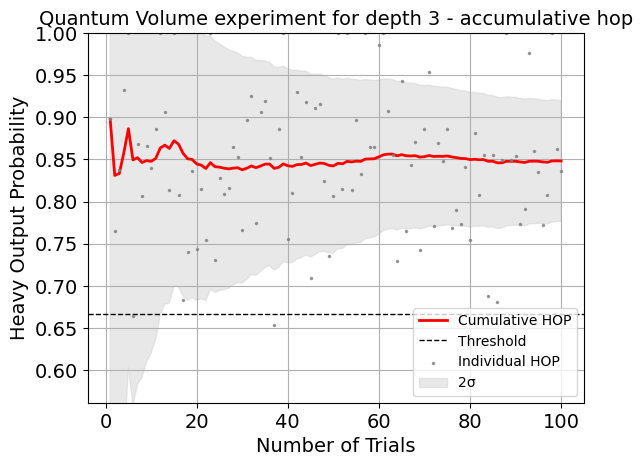

,name,experiment,components,value,quality,backend,run_time,HOPs,two_sigma,depth,trials,success,confidence
c66281d0,mean_HOP,QuantumVolume,"[Q0, Q1, Q2]",0.85+/-0.04,good,fake_manila,None,"[0.8974609375, 0.7646484375, 0.837890625, 0.93...",0.071755,3,100,None,None
b842b24b,quantum_volume,QuantumVolume,"[Q0, Q1, Q2]",8,good,fake_manila,None,None,None,3,100,True,1.0


In [3]:
qubits = tuple(range(3)) # Can use specific qubits. for example [2, 4, 7, 10]

qv_exp = QuantumVolume(qubits, seed=42)
# Transpile options like optimization_level affect only the real device run and not the simulation run
# Run options affect both simulation and real device runs
qv_exp.set_transpile_options(optimization_level=3)

# Run experiment
expdata = qv_exp.run(backend).block_for_results()
# View result data
display(expdata.figure(0))

display(expdata.analysis_results(dataframe=True))

# Adding trials
Adding more trials may reduce the error bars to allow passing the threshold (beside the error bars - QV experiment must have at least 100 trials to be considered successful). In case you want to add less than 100 additional trials, you can modify the amount of trials added before re-running the experiment.

/opt/conda/envs/qiskit/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/fake_backend.py:340: UserWarning: Option meas_level is not used by this backend
  job = self.sim.run(run_input, **options)


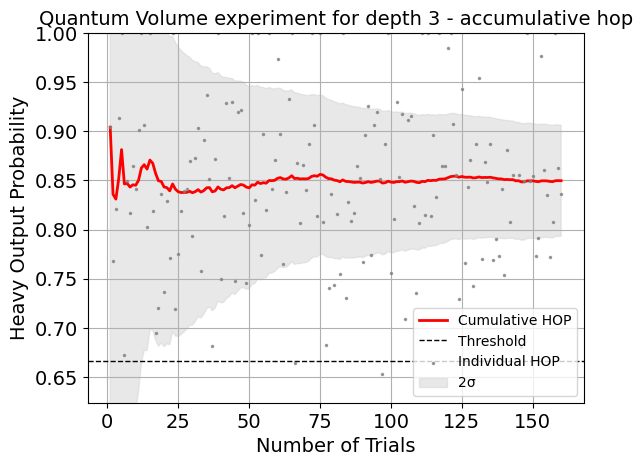

,name,experiment,components,value,quality,backend,run_time,HOPs,two_sigma,depth,trials,success,confidence
7dc4dbb5,mean_HOP,QuantumVolume,"[Q0, Q1, Q2]",0.850+/-0.028,good,fake_manila,None,"[0.904296875, 0.767578125, 0.8212890625, 0.914...",0.056499,3,160,None,None
2db59d23,quantum_volume,QuantumVolume,"[Q0, Q1, Q2]",8,good,fake_manila,None,None,None,3,160,True,1.0


In [4]:
qv_exp.set_experiment_options(trials=60)
expdata2 = qv_exp.run(backend, analysis=None).block_for_results()
expdata2.add_data(expdata.data())
qv_exp.analysis.run(expdata2).block_for_results()

# View result data
display(expdata2.figure(0))
display(expdata2.analysis_results(dataframe=True))

# Calculating Quantum Volume using a batch experiment
Run the QV experiment with an increasing number of qubits to check what is the maximum Quantum Volume for the specific device. To reach the real system’s Quantum Volume, one must run more trials and additional enhancements might be required (See Ref. [2] for details).

In [5]:
exps = [QuantumVolume(tuple(range(i)), trials=200) for i in range(3, 6)]

batch_exp = BatchExperiment(exps)
batch_exp.set_transpile_options(optimization_level=3)

# Run
batch_expdata = batch_exp.run(backend).block_for_results()

/opt/conda/envs/qiskit/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/fake_backend.py:340: UserWarning: Option meas_level is not used by this backend
  job = self.sim.run(run_input, **options)


Extracting the maximum Quantum Volume.

In [6]:
qv_values = batch_expdata.analysis_results("quantum_volume", dataframe=True).value.tolist()

print(f"Max quantum volume is: {max(qv_values)}")

Max quantum volume is: 32



Component experiment 0


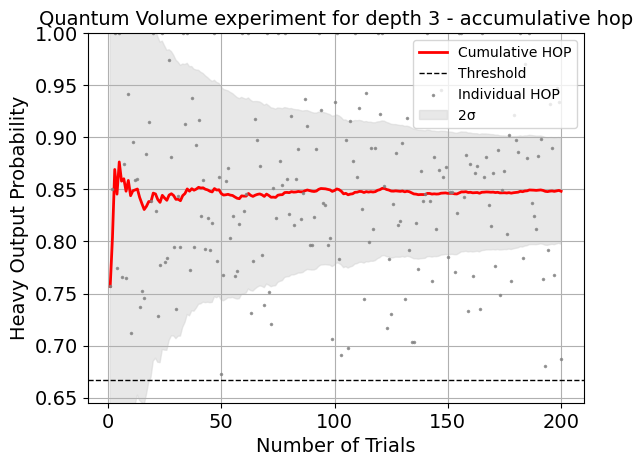


Component experiment 1


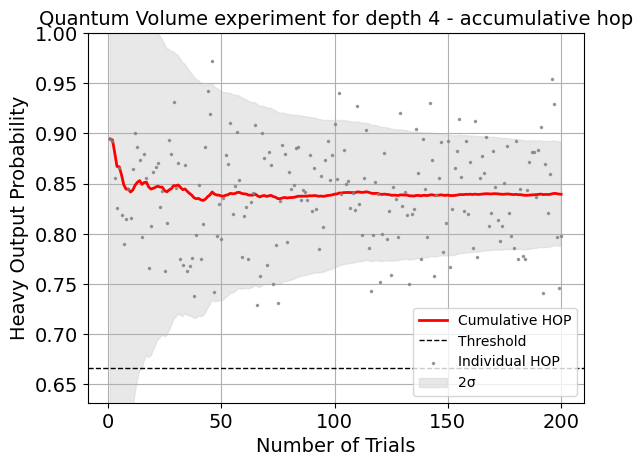


Component experiment 2


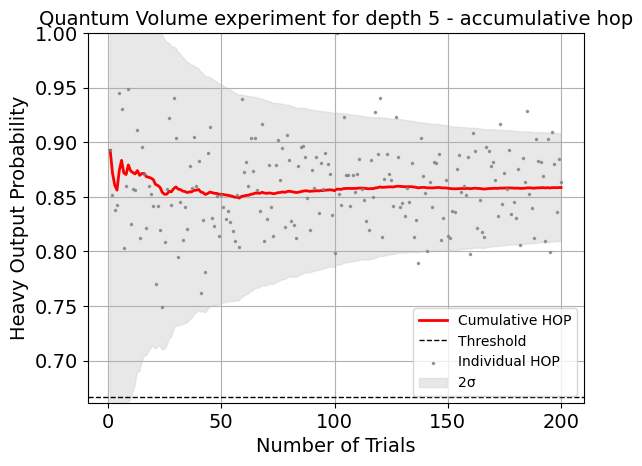

,name,experiment,components,value,quality,backend,run_time,HOPs,two_sigma,depth,trials,success,confidence
2f467268,mean_HOP,QuantumVolume,"[Q0, Q1, Q2]",0.848+/-0.025,good,fake_manila,None,"[0.7568359375, 0.8505859375, 1.0, 0.7744140625...",0.050743,3,200,None,None
82c47fe6,quantum_volume,QuantumVolume,"[Q0, Q1, Q2]",8,good,fake_manila,None,None,None,3,200,True,1.0
5e972941,mean_HOP,QuantumVolume,"[Q0, Q1, Q2, Q3]",0.839+/-0.026,good,fake_manila,None,"[0.89453125, 0.892578125, 0.85546875, 0.826171...",0.051918,4,200,None,None
a5f89a5f,quantum_volume,QuantumVolume,"[Q0, Q1, Q2, Q3]",16,good,fake_manila,None,None,None,4,200,True,1.0
058b9d31,mean_HOP,QuantumVolume,"[Q0, Q1, Q2, Q3, Q4]",0.859+/-0.025,good,fake_manila,None,"[0.892578125, 0.8515625, 0.837890625, 0.842773...",0.049281,5,200,None,None
3c254698,quantum_volume,QuantumVolume,"[Q0, Q1, Q2, Q3, Q4]",32,good,fake_manila,None,None,None,5,200,True,1.0


In [7]:
for i in range(batch_exp.num_experiments):
    print(f"\nComponent experiment {i}")
    display(batch_expdata.figure(i))
display(batch_expdata.analysis_results(dataframe=True))